## This notebook presents the result analysis and visualization for submission NCOMMS-26-018997-T

**Title:** *Impacts and Benefits of Electrified Space Heating on Renewable-Based Power Systems*

This notebook contains the analysis of simulation results and the corresponding visualizations prepared for the above submission.

Figure 2: Sensitivity analysis on social acceptance and building archetypes reveal different impacts on HP
demand and its flexibility potential.

**Contact:** Yi Guo  
**Email:** yi.guo@bit.edu.cn

In [1]:
# initialize all the packages necessary
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec

from scipy.io import loadmat
from scipy.interpolate import PchipInterpolator
from scipy.optimize import curve_fit

### Figure 2(a) and Figure 2(f): Define functions for loading data and quantifying annual flexibility

This section defines the utility functions used to read canton-level MATLAB output files, calculate annual flexibility metrics, and aggregate the results across Switzerland for different scenarios.

In [2]:
# Define a helper function to safely load MATLAB result files.
def load_flexibility_data(file_path):
    try:
        return loadmat(file_path)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None


# Extract annual flexibility, annual electricity consumption, and asset counts from one result file.
def calculate_flexibility(flexibility_origin):
    if flexibility_origin is None:
        return 0, 0, 0, 0

    Emax = flexibility_origin['Flexibilities'][0]['Emax'][0]
    Emin = flexibility_origin['Flexibilities'][0]['Emin'][0]
    Pbase = flexibility_origin['Flexibilities'][0]['Pbase'][0]
    Nbuildings = flexibility_origin['Flexibilities'][0]['N_buildings'][0]
    NHPs = flexibility_origin['Flexibilities'][0]['N_HPs'][0]

    # Calculate the annual aggregated flexibility using the 24th hourly value of each day.
    flex_agg_canton_year = sum(Emax[23, i] - Emin[23, i] for i in range(365))

    # Sum the baseline heat pump demand over the full year.
    energy_consumption_canton_year = Pbase.sum()

    return flex_agg_canton_year, energy_consumption_canton_year, Nbuildings[0][0], NHPs[0][0]


# Aggregate annual flexibility and consumption for all cantons and years within one scenario.
def analyze_flexibility(path_template):
    cantons = ['AG', 'AI', 'AR', 'BE', 'BL', 'BS', 'FR', 'GE', 'GL', 'GR', 'JU', 'LU', 'NE', 'NW', 'OW', 'SG', 'SH', 'SO',
               'SZ', 'TG', 'TI', 'UR', 'VD', 'VS', 'ZG', 'ZH']

    years = [str(year) for year in range(2021, 2051)]

    Aggregated_Flex_CH = np.zeros((30,))
    Aggregated_Consumption_CH = np.zeros((30,))

    for canton in cantons:
        data = []

        for year in years:
            file_path = path_template.format(year=year, canton=canton)
            flexibility_origin = load_flexibility_data(file_path)

            flex_agg_canton_year, energy_consumption_canton_year, Nbuildings, NHPs = calculate_flexibility(flexibility_origin)

            data.append({
                'Location': canton,
                'year': year,
                'aggregated_flex_year (GWh)': flex_agg_canton_year,
                'energy consumption year (GWh)': energy_consumption_canton_year,
                'N of Bldg': Nbuildings,
                'N of HPs': NHPs
            })

        # Save the canton-level annual results to an Excel workbook for later inspection.
        df = pd.DataFrame(
            data,
            columns=['Location', 'year', 'aggregated_flex_year (GWh)', 'energy consumption year (GWh)', 'N of Bldg', 'N of HPs']
        )

        file_path = 'Aggregated_flexibility_PROJECTION_per_canton_2021_2050.xlsx'

        with pd.ExcelWriter(file_path, engine='openpyxl', mode="a", if_sheet_exists='replace') as writer:
            df.to_excel(writer, index=True, sheet_name=canton)

        # Add the canton-level results to the national totals.
        for i, year in enumerate(years):
            Aggregated_Flex_CH[i] += data[i]['aggregated_flex_year (GWh)']
            Aggregated_Consumption_CH[i] += data[i]['energy consumption year (GWh)']

    return Aggregated_Flex_CH, Aggregated_Consumption_CH


# Define the scenario-specific path templates for the MATLAB result files.
paths = {
    '2A': '../Output_data/flexibility_demand_quantification/case2a/{year}/{canton}.mat',
    '2B': '../Output_data/flexibility_demand_quantification/case2b/{year}/{canton}.mat',
    '2C': '../Output_data/flexibility_demand_quantification/case2c/{year}/{canton}.mat',
    '3A': '../Output_data/flexibility_demand_quantification/case3a/{year}/{canton}.mat',
    '3B': '../Output_data/flexibility_demand_quantification/case3b/{year}/{canton}.mat',
    '3C': '../Output_data/flexibility_demand_quantification/case3c/{year}/{canton}.mat',
    '3D': '../Output_data/flexibility_demand_quantification/case3d/{year}/{canton}.mat'
}

# Run the aggregation for all scenarios and store the results in a dictionary.
results = {key: analyze_flexibility(path) for key, path in paths.items()}


### Figure 2(a) and Figure 2(f): Functions and analyses examine the sensitivity of the results to building archetypes, highlighting their distinct impacts on heat pump demand and flexibility.


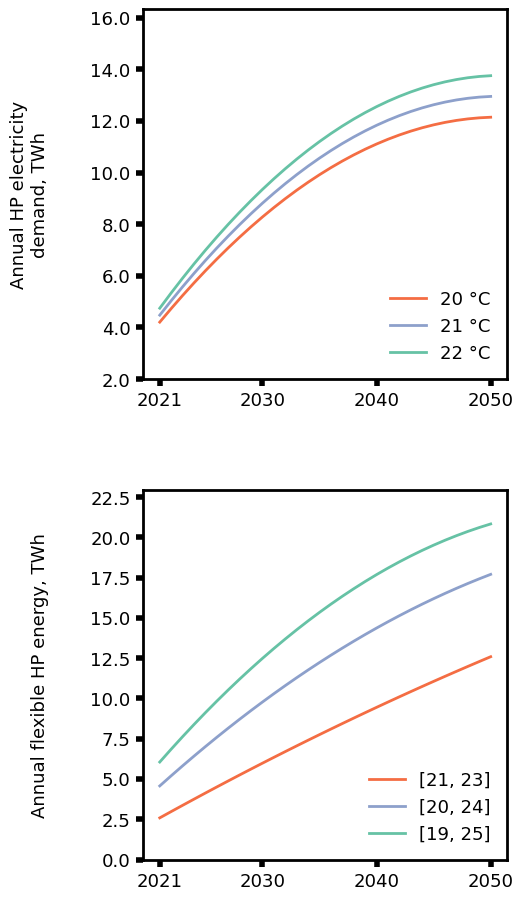

In [3]:
# ====================================================================================================
# This cell analyzes and visualizes the results shown in Fig. 2(a)-Fig. 2(f).
# ====================================================================================================

# Define figure-wide formatting parameters.
label_font_size = 13
title_font_size = 13
tick_font_size = 13
sublabel_font_size = 13
textlabel_font_size = 13
labelpad_size = 30
line_width = 12
marker_size = 20
legend_font_size = 20
years_to_display = [2021, 2030, 2040, 2050]

# Create a two-row figure layout for the sensitivity analysis panels.
fig, axs = plt.subplots(2, 1, figsize=(4, 10), edgecolor='black')

# Apply a consistent axis style across all subplots.
for ax in axs.flatten():
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    ax.tick_params(axis='x', which='major', pad=4, width=4, length=5)
    ax.tick_params(axis='y', which='major', pad=4, width=4, length=5)


# Format y-axis tick labels with one decimal place.
def format_yticks(ax):
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([f'{x:.1f}' for x in ax.get_yticks()], fontsize=tick_font_size)


time_stamp_v1 = [0, 9, 19, 29]
time_stamp_v1_labels = ['2021', '2030', '2040', '2050']


# Generate a smooth monotonic curve using PCHIP interpolation.
def fit_monotonic_curve(x, y, resolution=10):
    interpolator = PchipInterpolator(x, y)
    dense_x = np.linspace(x[0], x[-1], len(x) * resolution)
    dense_y = interpolator(dense_x)
    return dense_x, dense_y


# Plot one sensitivity panel with smoothed quadratic fits for multiple scenarios.
def plot_sensitivity(ax, x_data, y_data, labels, colors, ylabel, text_label):
    for y, label, color in zip(y_data, labels, colors):
        y = y.flatten()  # Ensure the input is one-dimensional.
        x = x_data

        # Fit a quadratic curve: y = ax^2 + bx + c.
        popt, _ = curve_fit(lambda x, a, b, c: a * x**2 + b * x + c, x, y)

        # Create a smoother x-grid for the fitted curve.
        x_fit = np.linspace(x.min(), x.max(), 30)
        y_fit = popt[0] * x_fit**2 + popt[1] * x_fit + popt[2]

        # Plot the fitted curve after converting GWh to TWh.
        ax.plot(x_fit, y_fit / 1000, linestyle='-', linewidth=2, color=color, label=label)

    ax.set_xticks(time_stamp_v1)
    ax.set_xticklabels(time_stamp_v1_labels, fontsize=tick_font_size)
    format_yticks(ax)
    # ax.set_xlabel('Years', fontsize=label_font_size, labelpad=30)
    ax.set_ylabel(ylabel, fontsize=label_font_size, labelpad=30)
    ax.legend(fontsize=label_font_size, loc='lower right', frameon=False)
    # ax.text(0, 1.10, text_label, transform=ax.transAxes, fontsize=sublabel_font_size, fontweight='bold', va='top')

    # Slightly expand the y-axis range to avoid visual overlap.
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * 1.02)


x_data = np.arange(30)

# Plot annual HP electricity demand under different indoor temperature assumptions.
plot_sensitivity(
    axs[0], x_data,
    [results['3A'][1], results['3B'][1], results['3C'][1]],
    ['20 °C', '21 °C', '22 °C'],
    ['#f46d43', '#8da0cb', '#66c2a5'],
    'Annual HP electricity\ndemand, TWh', '(a) Flexibility'
)

# Plot annual flexible HP energy under different comfort-band assumptions.
plot_sensitivity(
    axs[1], x_data,
    [results['2A'][0], results['2B'][0], results['2C'][0]],
    ['[21, 23]', '[20, 24]', '[19, 25]'],
    ['#f46d43', '#8da0cb', '#66c2a5'],
    'Annual flexible HP energy, TWh', '(b) Energy consumption'
)

# Finalize the layout and define a transparent figure background.
plt.tight_layout()
plt.subplots_adjust(left=0.08, right=0.99, top=0.95, bottom=0.1, wspace=0.4, hspace=0.3)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Additional SVG export settings to preserve editable text in Adobe Illustrator.
# Keep SVG text as real text rather than converting it to paths.
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False  # Avoid LaTeX rendering to prevent text-to-path conversion.
mpl.rcParams['font.family'] = ['Arial']

# # Define the SVG export path.
# out_path = Path.cwd() / "main_fig2a_2f.svg"

# # Save the figure as an SVG with a tight layout and transparent background settings.
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=False
# )
# print(f"Saved SVG to: {out_path}")

plt.show()


### Figure 2(b) - 2(e) and Figure 2(g) - 2(j): Define functions for loading data and quantifying flexibility and individual


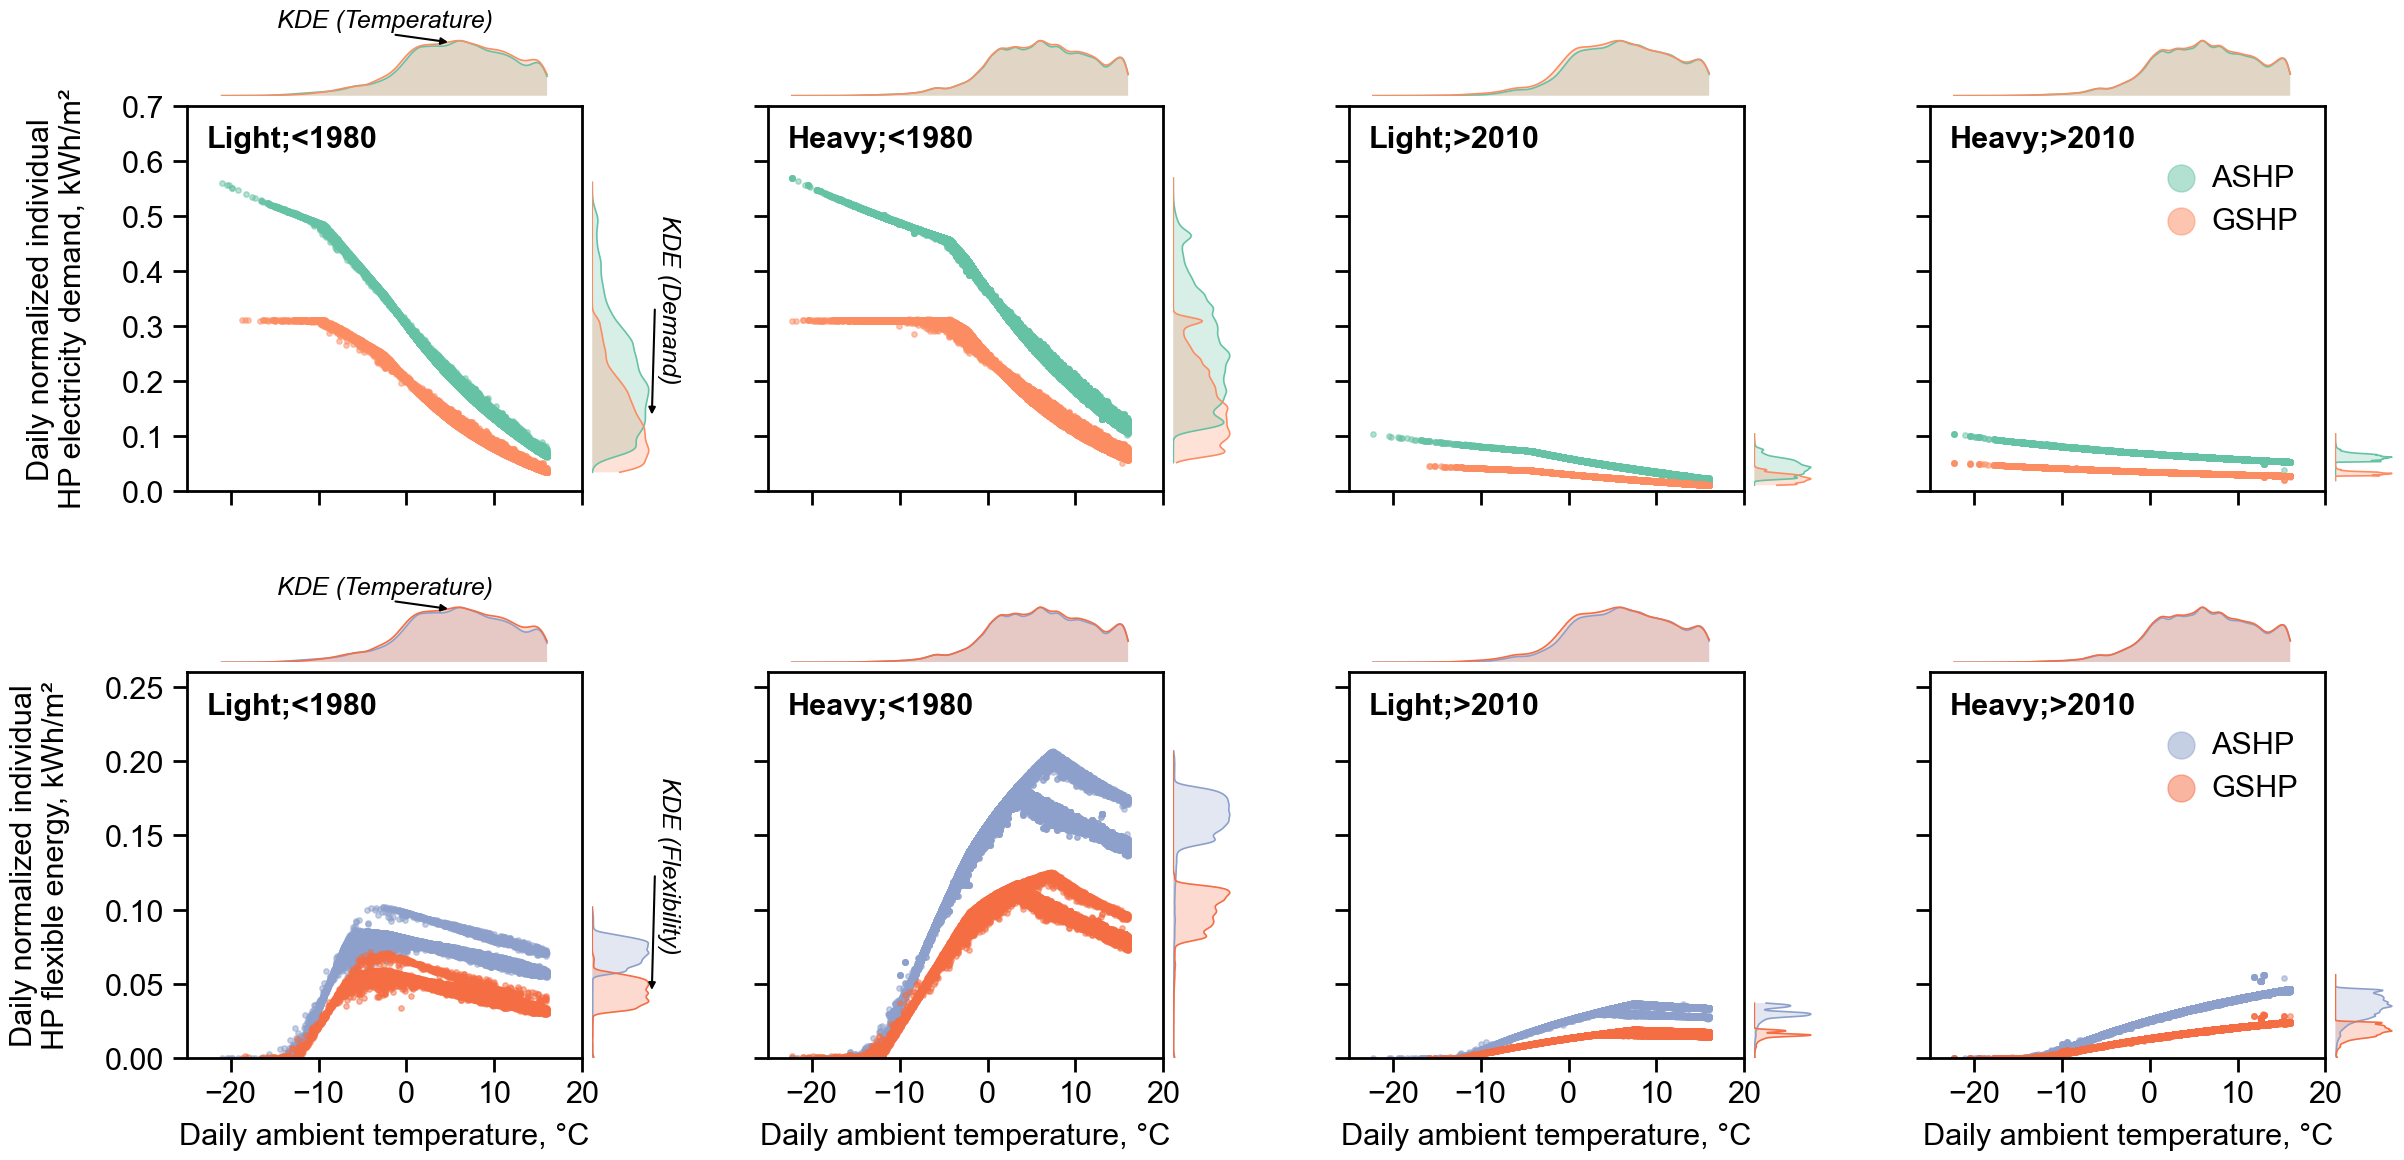

In [4]:
# ====================================================================================================
# This cell analyses and visualizes the results as shown in Fig.2(b) - Fig.2(e) and Fig.2(g) - Fig.2(i)
# ====================================================================================================

# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import os
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl
from pathlib import Path

# =============== Parameters ===============
label_font_size = 22
tick_font_size = 22
sublabel_font_size = 22
labelpad_size = 10
line_width = 2
marker_size = 15
legend_font_size = 22

# Ticks (outward only)
MAJOR_TICK_LEN = 10
MINOR_TICK_LEN = 6
TICK_PAD = 6

# Automatic x-axis ticks shared by both rows
X_MAJOR_STEP = 10
X_MINOR_STEP = 1.0

# Top row (Demand) y-axis settings
Y_MAJOR_STEP_DEM = 0.1
Y_MINOR_STEP_DEM = 0.05
Y_LIM_DEM = (0, 0.7)

# Bottom row (Flexibility) y-axis settings
Y_MAJOR_STEP_FLEX = 0.05
Y_MINOR_STEP_FLEX = 0.01
Y_LIM_FLEX = (0, 0.26)

# Colors: use separate palettes for the top and bottom rows
COLORS_TOP    = {"ASHP": "#66c2a5", "GSHP": "#fc8d62"}  # blue / orange for demand
COLORS_BOTTOM = {"ASHP": "#8da0cb",  # light purple-gray for flexibility
                 "GSHP": "#f46d43"}  # light green-gray for flexibility

ALPHA_PT = 0.5
ALPHA_KDE = 0.25
KDE_N = 256

# KDE annotations
KDE_TEXT_KW = dict(fontsize=18, fontstyle='italic',
                   bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
KDE_ARROW_KW = dict(arrowstyle='-|>', color='black', lw=1.5, shrinkA=8, shrinkB=8)

# =============== Core helper functions ===============
def apply_axis_style(ax):
    # Major ticks: keep the full length and padding for labeled ticks
    ax.tick_params(axis='both', which='major',
                   direction='out', length=MAJOR_TICK_LEN, width=2.0,
                   colors='black', pad=TICK_PAD)

    # Minor ticks: remove length and padding, and hide the labels
    ax.tick_params(axis='both', which='minor',
                   direction='out', length=0, width=0,
                   colors='black', pad=0,
                   labelbottom=False, labelleft=False, labelright=False, labeltop=False)

    for sp in ax.spines.values():
        sp.set_linewidth(line_width); sp.set_color('black')

    ax.tick_params(labelsize=tick_font_size)
    ax.minorticks_on()   # This can be kept; minor ticks are still located but visually hidden because their length and padding are set to zero
    ax.grid(False); ax.set_axisbelow(False)

def set_locators(ax, x_major=None, x_minor=None, y_major=None, y_minor=None):
    if x_major is not None: ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if x_minor is not None: ax.xaxis.set_minor_locator(MultipleLocator(x_minor))
    if y_major is not None: ax.yaxis.set_major_locator(MultipleLocator(y_major))
    if y_minor is not None: ax.yaxis.set_minor_locator(MultipleLocator(y_minor))

def safe_flat(a): return np.squeeze(a).flatten()

def kde_1d(values, xmin, xmax, n=KDE_N, bw=None):
    v = np.asarray(values); v = v[np.isfinite(v)]
    if v.size < 5 or np.allclose(v.min(), v.max()): return None
    kde = gaussian_kde(v, bw_method=bw)
    grid = np.linspace(xmin, xmax, n); pdf = kde(grid)
    if pdf.max() > 0: pdf = pdf / pdf.max()
    return grid, pdf

def annotate_kde(ax_top, ax_right, kdet1, kdet2, kdey1, kdey2, right_label):
    # Top axis: KDE for temperature
    if (kdet1 is not None) or (kdet2 is not None):
        if kdet1 is not None and kdet2 is not None:
            gx = kdet1[0]; gsum = kdet1[1] + kdet2[1]
        elif kdet1 is not None: gx, gsum = kdet1
        else: gx, gsum = kdet2
        x_peak = gx[np.argmax(gsum)]
        ax_top.text(0.5, 1.10, "KDE (Temperature)", transform=ax_top.transAxes,
                    ha='center', va='bottom', **KDE_TEXT_KW)
        ax_top.annotate('', xy=(x_peak, 0.9), xycoords=('data', 'axes fraction'),
                        xytext=(0.5, 1.08), textcoords='axes fraction',
                        arrowprops=KDE_ARROW_KW)
    # Right axis: KDE for demand/flexibility
    if (kdey1 is not None) or (kdey2 is not None):
        if kdey1 is not None and kdey2 is not None:
            gy = kdey1[0]; gsum = kdey1[1] + kdey2[1]
        elif kdey1 is not None: gy, gsum = kdey1
        else: gy, gsum = kdey2
        y_peak = gy[np.argmax(gsum)]
        ax_right.text(1.10, 0.5, right_label, transform=ax_right.transAxes,
                      rotation=270, ha='left', va='center', **KDE_TEXT_KW)
        ax_right.annotate('', xy=(1.0, y_peak), xycoords=('axes fraction', 'data'),
                          xytext=(1.06, 0.5), textcoords='axes fraction',
                          arrowprops=KDE_ARROW_KW)

def draw_panel(ax_main, x1, y1, x2, y2, title_text, colors,
               xlim=(-25, 20), ylim=(0, 0.7),
               locators=(X_MAJOR_STEP, X_MINOR_STEP, None, None),
               first_panel=False, right_kde_label="KDE", put_legend=False):
    # Main panel
    ax_main.set_xlim(*xlim); ax_main.set_ylim(*ylim)
    ax_main.scatter(x1, y1, s=marker_size, alpha=ALPHA_PT, color=colors["ASHP"], label='ASHP', rasterized=True)
    ax_main.scatter(x2, y2, s=marker_size, alpha=ALPHA_PT, color=colors["GSHP"], label='GSHP', rasterized=True)
    ax_main.text(0.05, 0.95, title_text, transform=ax_main.transAxes,
                 fontsize=sublabel_font_size, va='top', ha='left', weight='bold')
    apply_axis_style(ax_main)
    set_locators(ax_main, *locators)

    # Marginal KDE axes
    divider = make_axes_locatable(ax_main)
    ax_top   = divider.append_axes("top",   size="15%", pad=0.1, sharex=ax_main)
    ax_right = divider.append_axes("right", size="15%", pad=0.1, sharey=ax_main)

    xmin, xmax = min(np.min(x1), np.min(x2)), max(np.max(x1), np.max(x2))
    ymin, ymax = min(np.min(y1), np.min(y2)), max(np.max(y1), np.max(y2))

    kdet1 = kde_1d(x1, xmin, xmax); kdet2 = kde_1d(x2, xmin, xmax)
    kdey1 = kde_1d(y1, ymin, ymax); kdey2 = kde_1d(y2, ymin, ymax)

    # Top KDE
    if kdet1 is not None:
        gx, gpdf = kdet1
        ax_top.fill_between(gx, 0, gpdf, alpha=ALPHA_KDE, edgecolor='none', facecolor=colors["ASHP"])
        ax_top.plot(gx, gpdf, linewidth=1.2, color=colors["ASHP"])
    if kdet2 is not None:
        gx, gpdf = kdet2
        ax_top.fill_between(gx, 0, gpdf, alpha=ALPHA_KDE, edgecolor='none', facecolor=colors["GSHP"])
        ax_top.plot(gx, gpdf, linewidth=1.2, color=colors["GSHP"])
    ax_top.set_ylim(0, 1.05); ax_top.axis("off")

    # Right KDE
    if kdey1 is not None:
        gy, gpdf = kdey1
        ax_right.fill_betweenx(gy, 0, gpdf, alpha=ALPHA_KDE, edgecolor='none', facecolor=colors["ASHP"])
        ax_right.plot(gpdf, gy, linewidth=1.2, color=colors["ASHP"])
    if kdey2 is not None:
        gy, gpdf = kdey2
        ax_right.fill_betweenx(gy, 0, gpdf, alpha=ALPHA_KDE, edgecolor='none', facecolor=colors["GSHP"])
        ax_right.plot(gpdf, gy, linewidth=1.2, color=colors["GSHP"])
    ax_right.set_xlim(0, 1.05); ax_right.axis("off")

    # add KDE annotations in the first column
    if first_panel:
        annotate_kde(ax_top, ax_right, kdet1, kdet2, kdey1, kdey2, right_label=right_kde_label)

    # Place the legend only in the fourth subplot of each row
    if put_legend:
        ax_main.legend(loc='upper right', frameon=False, fontsize=legend_font_size, bbox_to_anchor=(1, 0.92),
               handlelength=1.2, handletextpad=0.4, markerscale=5)

# =============== Load data ===============
base_path = r'../Output_data'
file_name = r'flexibility_temperature_ch_2024_Tset22.0_10000_RCP26_Quant50_Category II.mat'
results = scipy.io.loadmat(os.path.join(base_path, file_name))['results'][0, 0]

# Grouping indices
group_indices = []
for iHP in (1, 2):
    for ibc in (1, 2, 3):
        for iyg in (1, 2, 3, 4):
            idx = np.where(
                (results['HP_type'] == iHP) &
                (results['building_construction'] == ibc) &
                (results['building_year_group'] == iyg)
            )[0]
            group_indices.append(idx)

subplot_titles = [
    "Light;<1980", "Light;1980-2000", "Light;2000-2010", "Light;>2010",
    "Medium;<1980", "Medium;1980-2000", "Medium;2000-2010", "Medium;>2010",
    "Heavy;<1980", "Heavy;1980-2000", "Heavy;2000-2010", "Heavy;>2010"
]
selected_idx = [0, 8, 3, 11]

# =============== Plotting routine (2×4) ===============
xlim = (-25, 20)
fig = plt.figure(figsize=(24, 12))
gs = GridSpec(2, 4, figure=fig, left=0.06, right=0.98, top=0.95, bottom=0.10,
              wspace=0.25, hspace=0.25)

axes_top, axes_bot = [], []

# -------- Top row: Demand (COLORS_TOP) --------
for j, i in enumerate(selected_idx):
    x1 = safe_flat(results['avg_temp'][group_indices[i], :])
    y1 = safe_flat(results['baseline_energy_per_m2'][group_indices[i], :])
    x2 = safe_flat(results['avg_temp'][group_indices[i + 12], :])
    y2 = safe_flat(results['baseline_energy_per_m2'][group_indices[i + 12], :])

    m1 = y1 != 0; m2 = y2 != 0
    x1, y1 = x1[m1], y1[m1]; x2, y2 = x2[m2], y2[m2]

    ax = fig.add_subplot(gs[0, j]); axes_top.append(ax)
    draw_panel(ax, x1, y1, x2, y2, subplot_titles[i], COLORS_TOP,
               xlim=xlim, ylim=Y_LIM_DEM,
               locators=(X_MAJOR_STEP, X_MINOR_STEP, Y_MAJOR_STEP_DEM, Y_MINOR_STEP_DEM),
               first_panel=(j == 0), right_kde_label="KDE (Demand)",
               put_legend=(j == 3))

# -------- Bottom row: Flexibility (COLORS_BOTTOM) --------
for j, i in enumerate(selected_idx):
    x1 = safe_flat(results['avg_temp'][group_indices[i], :])
    y1 = safe_flat(results['flexibilities_per_m2'][group_indices[i], :])
    x2 = safe_flat(results['avg_temp'][group_indices[i + 12], :])
    y2 = safe_flat(results['flexibilities_per_m2'][group_indices[i + 12], :])

    m1 = y1 != 0; m2 = y2 != 0
    x1, y1 = x1[m1], y1[m1]; x2, y2 = x2[m2], y2[m2]

    ax = fig.add_subplot(gs[1, j]); axes_bot.append(ax)
    draw_panel(ax, x1, y1, x2, y2, subplot_titles[i], COLORS_BOTTOM,
               xlim=xlim, ylim=Y_LIM_FLEX,
               locators=(X_MAJOR_STEP, X_MINOR_STEP, Y_MAJOR_STEP_FLEX, Y_MINOR_STEP_FLEX),
               first_panel=(j == 0), right_kde_label="KDE (Flexibility)",
               put_legend=(j == 3))

# Axis labels: show x-labels on the bottom row and one y-label on the left of each row
for ax in axes_top: ax.set_xlabel(""); ax.tick_params(labelbottom=False)
for ax in axes_bot: ax.set_xlabel("Daily ambient temperature, °C",
                                  fontsize=label_font_size, labelpad=labelpad_size)

axes_top[0].set_ylabel("Daily normalized individual\nHP electricity demand, kWh/m²",
                       fontsize=label_font_size, labelpad=labelpad_size+15)
for ax in axes_top[1:]: ax.set_ylabel(""); ax.tick_params(labelleft=False)

axes_bot[0].set_ylabel("Daily normalized individual\nHP flexible energy, kWh/m²",
                       fontsize=label_font_size, labelpad=labelpad_size+15)
for ax in axes_bot[1:]: ax.set_ylabel(""); ax.tick_params(labelleft=False)

plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'

# ======================= Additional step: SVG export (text remains editable in Adobe Illustrator) =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Disable LaTeX text rendering to avoid converting text to outlines
mpl.rcParams['font.family'] = ['Arial']

# # Export path (modify as needed)
# out_path = Path.cwd() / "Main_fig2b-2e_fig2g-2i.svg"

# # Save as SVG with a transparent background and tight bounding box
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ================================================================================

plt.show()
